# UA-SER Minimal Start

Load `OlhaHavryliuk/UA-SER`, read `dataset.csv`, and make the first compact dataset overview.

In [35]:
from pathlib import Path
import os

import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import librosa
from datasets import load_dataset, Audio
from huggingface_hub import hf_hub_download

pd.set_option('display.max_colwidth', None)

SEED = 1488
DATASET_ID = 'OlhaHavryliuk/UA-SER'
WORK_DIR = Path('/kaggle/working') if Path('/kaggle').exists() else Path.cwd()

print('work_dir:', WORK_DIR)
print('dataset:', DATASET_ID)

work_dir: /kaggle/working
dataset: OlhaHavryliuk/UA-SER


In [36]:
ds = load_dataset(DATASET_ID)
train_ds = ds['train']

print(ds)
print('rows:', len(train_ds))
print('columns:', train_ds.column_names)
print('features:', train_ds.features)

Resolving data files:   0%|          | 0/953 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['audio'],
        num_rows: 952
    })
})
rows: 952
columns: ['audio']
features: {'audio': Audio(sampling_rate=None, decode=True, num_channels=None, stream_index=None)}


## Metadata

In [37]:
metadata_path = hf_hub_download(
    repo_id=DATASET_ID,
    filename='dataset.csv',
    repo_type='dataset',
)

df = pd.read_csv(metadata_path)
df['gender'] = df['filename'].str.extract(r'_(\d)\.wav$')[0].map({'0': 'male', '1': 'female'})

print('metadata_path:', metadata_path)
print('shape:', df.shape)
print('columns:', list(df.columns))
display(df.head())

metadata_path: /root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9/dataset.csv
shape: (952, 7)
columns: ['filename', 'emotion', 'duration_seconds', 'text', 'speaker_id', 'split', 'gender']


,filename,emotion,duration_seconds,text,speaker_id,split,gender
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,female
1,s_002_1.wav,sad,1.54,Але я тебе ніколи не бачила.,107,test,female
2,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,male
3,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,female
4,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,female


## Match Metadata to Audio Paths

In [38]:
train_paths = ds.cast_column('audio', Audio(decode=False))['train']

path_rows = []
for row in train_paths:
    path = Path(row['audio']['path'])
    path_rows.append({'filename': path.name, 'path': str(path)})

paths_df = pd.DataFrame(path_rows)
df = df.merge(paths_df, on='filename', how='left')

print('audio paths:', len(paths_df))
print('missing paths after merge:', int(df['path'].isna().sum()))
display(df.head())

audio paths: 952
missing paths after merge: 0


,filename,emotion,duration_seconds,text,speaker_id,split,gender,path
0,s_001_1.wav,sad,1.86,"Якщо в тебе щось не виходить,",166,train,female,/root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9/clips/s_001_1.wav
1,s_002_1.wav,sad,1.54,Але я тебе ніколи не бачила.,107,test,female,/root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9/clips/s_002_1.wav
2,s_003_0.wav,sad,1.72,Якраз для дівчаток. Тримай.,58,train,male,/root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9/clips/s_003_0.wav
3,s_004_1.wav,sad,2.08,Я цих 700 грн ділила на 30 днів.,37,train,female,/root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9/clips/s_004_1.wav
4,s_005_1.wav,sad,1.54,Нічого не відчуваю.,176,train,female,/root/.cache/huggingface/hub/datasets--OlhaHavryliuk--UA-SER/snapshots/c3fc0b0ef8d40f133d7a74e804ab6f376ef53aa9/clips/s_005_1.wav


In [39]:
print('split x emotion')
display(pd.crosstab(df['emotion'], df['split'], margins=True))

print('gender counts')
display(df['gender'].value_counts(dropna=False).to_frame('count'))

print('speakers:', df['speaker_id'].nunique())
print('duration summary')
display(df['duration_seconds'].describe().to_frame().T)

split x emotion


split,test,train,All
emotion,,,
angry,49,210,259
happy,44,200,244
neutral,42,180,222
sad,46,181,227
All,181,771,952


gender counts


,count
gender,
female,593
male,359


speakers: 400
duration summary


,count,mean,std,min,25%,50%,75%,max
duration_seconds,952.0,2.065641,0.74845,0.52,1.5275,1.99,2.55,5.5


## Tiny Audio Probe

In [40]:
probe_rows = []
for i, row in df.head(10).reset_index(drop=True).iterrows():
    try:
        info = sf.info(row['path'])
        probe_rows.append({
            'idx': i,
            'filename': row['filename'],
            'emotion': row['emotion'],
            'split': row['split'],
            'gender': row['gender'],
            'sampling_rate': info.samplerate,
            'duration_sec': round(info.frames / info.samplerate, 3),
            'channels': info.channels,
        })
    except Exception as e:
        probe_rows.append({'idx': i, 'filename': row['filename'], 'error': repr(e)[:160]})

pd.DataFrame(probe_rows)

,idx,filename,emotion,split,gender,sampling_rate,duration_sec,channels
0,0,s_001_1.wav,sad,train,female,16000,1.856,1
1,1,s_002_1.wav,sad,test,female,16000,1.536,1
2,2,s_003_0.wav,sad,train,male,16000,1.721,1
3,3,s_004_1.wav,sad,train,female,16000,2.076,1
4,4,s_005_1.wav,sad,train,female,16000,1.536,1
5,5,s_006_1.wav,sad,test,female,16000,1.920,1
6,6,s_007_0.wav,sad,train,male,16000,1.102,1
7,7,s_008_1.wav,sad,train,female,16000,3.004,1
8,8,s_009_0.wav,sad,train,male,16000,1.558,1
9,9,s_010_1.wav,sad,train,female,16000,0.896,1


## Train / Validation / Test Split

In [41]:
from sklearn.model_selection import StratifiedGroupKFold

df['split3'] = 'test'

native_train = df[df['split'] == 'train'].copy()
stratify_key = native_train['emotion'].astype(str) + '_' + native_train['gender'].astype(str)

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
train_pos, val_pos = next(sgkf.split(native_train, y=stratify_key, groups=native_train['speaker_id']))

train_index = native_train.iloc[train_pos].index
val_index = native_train.iloc[val_pos].index

df.loc[train_index, 'split3'] = 'train'
df.loc[val_index, 'split3'] = 'val'

print('split3 counts')
display(df['split3'].value_counts().reindex(['train', 'val', 'test']).to_frame('count'))

for left, right in [('train', 'val'), ('train', 'test'), ('val', 'test')]:
    left_speakers = set(df.loc[df['split3'] == left, 'speaker_id'])
    right_speakers = set(df.loc[df['split3'] == right, 'speaker_id'])
    print(f'{left}/{right} speaker overlap:', len(left_speakers & right_speakers))

split3 counts


,count
split3,
train,615
val,156
test,181


train/val speaker overlap: 0
train/test speaker overlap: 0
val/test speaker overlap: 0


In [42]:
print('emotion balance')
display(pd.crosstab(df['emotion'], df['split3'], margins=True))

print('gender balance')
display(pd.crosstab(df['gender'], df['split3'], margins=True))

split_summary = df.groupby('split3').agg(
    clips=('filename', 'size'),
    speakers=('speaker_id', 'nunique'),
    duration_min=('duration_seconds', lambda x: round(x.sum() / 60, 2)),
).reindex(['train', 'val', 'test'])

display(split_summary)

manifest_path = WORK_DIR / 'ua_ser_manifest.csv'
df.to_csv(manifest_path, index=False)

emotion balance


split3,test,train,val,All
emotion,,,,
angry,49,171,39,259
happy,44,153,47,244
neutral,42,150,30,222
sad,46,141,40,227
All,181,615,156,952


gender balance


split3,test,train,val,All
gender,,,,
female,98,391,104,593
male,83,224,52,359
All,181,615,156,952


,clips,speakers,duration_min
split3,,,
train,615,282,21.30
val,156,66,5.49
test,181,52,5.98


## Balance Plots

/tmp/ipykernel_101/2972036222.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(duration_data, labels=split_order, showfliers=False)


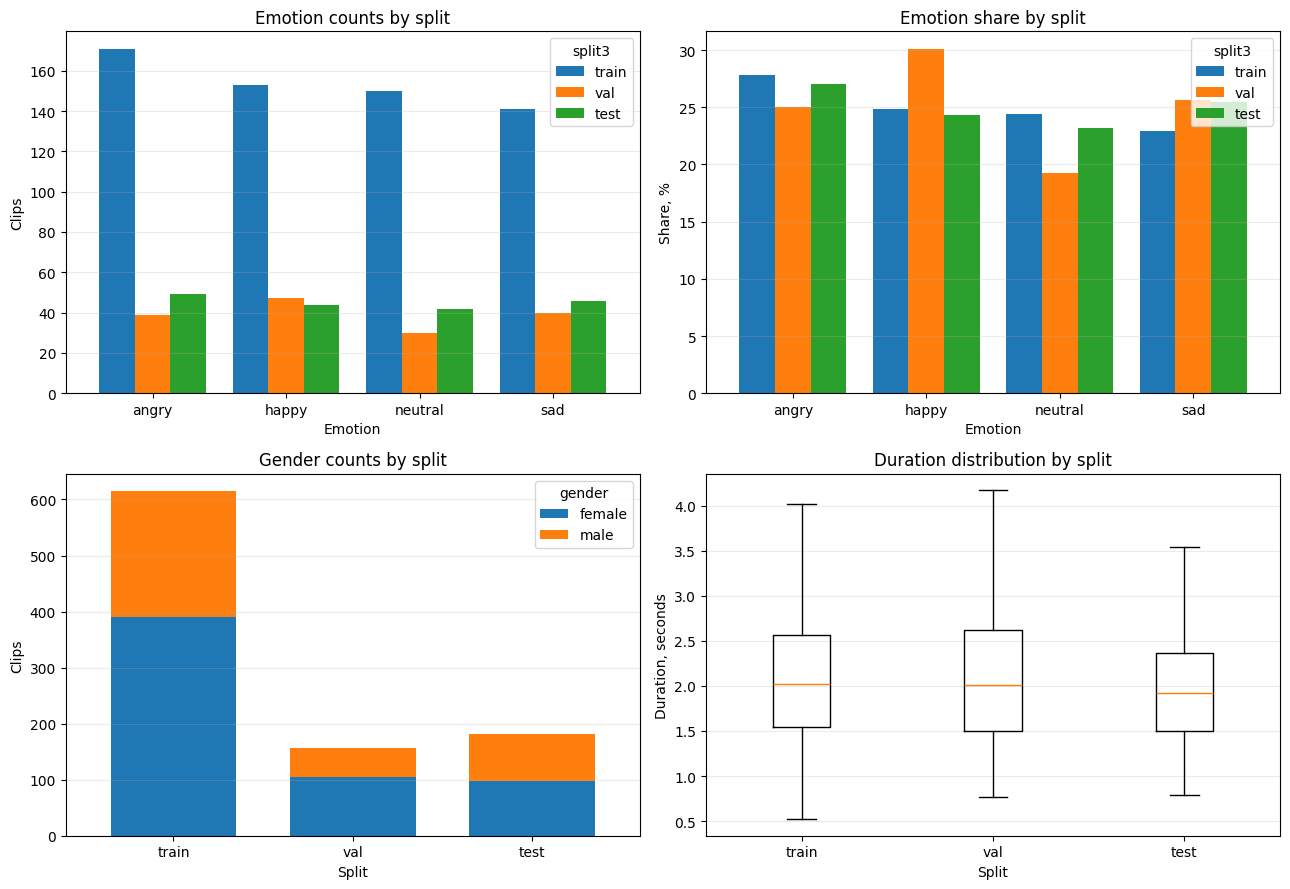

In [43]:
split_order = ['train', 'val', 'test']
emotion_order = ['angry', 'happy', 'neutral', 'sad']
gender_order = ['female', 'male']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

emotion_counts = pd.crosstab(df['emotion'], df['split3']).reindex(emotion_order)[split_order]
emotion_counts.plot(kind='bar', ax=axes[0, 0], width=0.8)
axes[0, 0].set_title('Emotion counts by split')
axes[0, 0].set_xlabel('Emotion')
axes[0, 0].set_ylabel('Clips')
axes[0, 0].tick_params(axis='x', rotation=0)

emotion_pct = emotion_counts.div(emotion_counts.sum(axis=0), axis=1) * 100
emotion_pct.plot(kind='bar', ax=axes[0, 1], width=0.8)
axes[0, 1].set_title('Emotion share by split')
axes[0, 1].set_xlabel('Emotion')
axes[0, 1].set_ylabel('Share, %')
axes[0, 1].tick_params(axis='x', rotation=0)

gender_counts = pd.crosstab(df['split3'], df['gender']).reindex(split_order)[gender_order]
gender_counts.plot(kind='bar', stacked=True, ax=axes[1, 0], width=0.7)
axes[1, 0].set_title('Gender counts by split')
axes[1, 0].set_xlabel('Split')
axes[1, 0].set_ylabel('Clips')
axes[1, 0].tick_params(axis='x', rotation=0)

duration_data = [df.loc[df['split3'] == split, 'duration_seconds'] for split in split_order]
axes[1, 1].boxplot(duration_data, labels=split_order, showfliers=False)
axes[1, 1].set_title('Duration distribution by split')
axes[1, 1].set_xlabel('Split')
axes[1, 1].set_ylabel('Duration, seconds')

for ax in axes.flat:
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## Spectral Features Baseline

In [44]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import librosa
from sklearn.base import clone
from lightgbm import LGBMClassifier


FEATURE_CACHE = WORK_DIR / 'ua_ser_spectral_features.csv'
LABEL_ORDER = ['angry', 'happy', 'neutral', 'sad']

In [45]:
def add_summary(features, prefix, values):
    values = np.asarray(values)
    for i in range(values.shape[0]):
        row = values[i]
        features[f'{prefix}_{i:02d}_mean'] = float(np.mean(row))
        features[f'{prefix}_{i:02d}_std'] = float(np.std(row))


def extract_spectral_features(path, target_sr=16000):
    y, sr = librosa.load(path, sr=target_sr, mono=True)
    if len(y) == 0:
        return {}

    features = {}
    features['duration_sec_loaded'] = float(len(y) / sr)

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64)
    logmel = librosa.power_to_db(mel, ref=np.max)

    add_summary(features, 'mfcc', mfcc)
    add_summary(features, 'logmel', logmel)

    single_features = {
        'rms': librosa.feature.rms(y=y),
        'zcr': librosa.feature.zero_crossing_rate(y),
        'centroid': librosa.feature.spectral_centroid(y=y, sr=sr),
        'bandwidth': librosa.feature.spectral_bandwidth(y=y, sr=sr),
        'rolloff': librosa.feature.spectral_rolloff(y=y, sr=sr),
    }

    for name, arr in single_features.items():
        row = arr[0]
        features[f'{name}_mean'] = float(np.mean(row))
        features[f'{name}_std'] = float(np.std(row))
        features[f'{name}_min'] = float(np.min(row))
        features[f'{name}_max'] = float(np.max(row))

    return features


if FEATURE_CACHE.exists():
    features_df = pd.read_csv(FEATURE_CACHE)
    print('loaded cached features:', features_df.shape)
else:
    rows = []
    for i, row in df.reset_index(drop=True).iterrows():
        feats = extract_spectral_features(row['path'])
        feats.update({
            'filename': row['filename'],
            'emotion': row['emotion'],
            'split3': row['split3'],
            'speaker_id': row['speaker_id'],
            'gender': row['gender'],
        })
        rows.append(feats)
        if (i + 1) % 100 == 0 or (i + 1) == len(df):
            print(f'extracted {i + 1}/{len(df)}')

    features_df = pd.DataFrame(rows)
    features_df.to_csv(FEATURE_CACHE, index=False)
    print('saved features:', FEATURE_CACHE)

print('features shape:', features_df.shape)
display(features_df[['filename', 'emotion', 'split3', 'gender']].head())

loaded cached features: (952, 194)
features shape: (952, 194)


,filename,emotion,split3,gender
0,s_001_1.wav,sad,train,female
1,s_002_1.wav,sad,test,female
2,s_003_0.wav,sad,train,male
3,s_004_1.wav,sad,train,female
4,s_005_1.wav,sad,val,female


In [46]:
meta_cols = {'filename', 'emotion', 'split3', 'speaker_id', 'gender'}
feature_cols = [c for c in features_df.columns if c not in meta_cols]

train_mask = features_df['split3'] == 'train'
val_mask = features_df['split3'] == 'val'
test_mask = features_df['split3'] == 'test'

X_train = features_df.loc[train_mask, feature_cols].fillna(0)
y_train = features_df.loc[train_mask, 'emotion']
X_val = features_df.loc[val_mask, feature_cols].fillna(0)
y_val = features_df.loc[val_mask, 'emotion']
X_test = features_df.loc[test_mask, feature_cols].fillna(0)
y_test = features_df.loc[test_mask, 'emotion']

print('X shapes:', X_train.shape, X_val.shape, X_test.shape)
print('feature count:', len(feature_cols))

X shapes: (615, 189) (156, 189) (181, 189)
feature count: 189


In [53]:
models = {
    'majority_dummy': DummyClassifier(strategy='most_frequent'),
    'logreg': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    ),
    'rbf_svm': make_pipeline(
        StandardScaler(),
        SVC(C=3.0, gamma='scale', class_weight='balanced', random_state=SEED),
    ),
    'random_forest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=SEED,
        n_jobs=-1,
    ),
    'lightgbm': LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        class_weight='balanced',
        random_state=SEED,
        verbosity=-1,
    ),
    'mlp': make_pipeline(
        StandardScaler(),
        MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation='relu',
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=800,
            early_stopping=False,
            random_state=SEED,
        ),
    ),
}

results = []
fitted_models = {}

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        fitted_models[name] = model
        pred = model.predict(X_val)
        results.append({
            'model': name,
            'split': 'val',
            'UAR': balanced_accuracy_score(y_val, pred),
            'Accuracy': accuracy_score(y_val, pred),
            'Macro F1': f1_score(y_val, pred, average='macro'),
        })
    except Exception as e:
        results.append({
            'model': name,
            'split': 'val',
            'UAR': np.nan,
            'Accuracy': np.nan,
            'Macro F1': np.nan,
        })
        print(f'{name} failed:', repr(e)[:180])

results_df = pd.DataFrame(results).sort_values('UAR', ascending=False)
display(results_df)

,model,split,UAR,Accuracy,Macro F1
4,lightgbm,val,0.580309,0.589744,0.581203
5,mlp,val,0.518235,0.532051,0.518775
2,rbf_svm,val,0.487207,0.506410,0.487178
3,random_forest,val,0.466564,0.480769,0.468253
1,logreg,val,0.441793,0.448718,0.442004
0,majority_dummy,val,0.250000,0.250000,0.100000


In [48]:
best_model_name = results_df.iloc[0]['model']
best_model = fitted_models[best_model_name]

print('best validation model:', best_model_name)

for split_name, X_split, y_split in [('val', X_val, y_val), ('test', X_test, y_test)]:
    pred = best_model.predict(X_split)
    print('\n', split_name)
    print('UAR:', round(balanced_accuracy_score(y_split, pred), 4))
    print('Accuracy:', round(accuracy_score(y_split, pred), 4))
    print('Macro F1:', round(f1_score(y_split, pred, average='macro'), 4))
    print(classification_report(y_split, pred, labels=LABEL_ORDER, digits=3, zero_division=0))

best validation model: lightgbm

 val
UAR: 0.5803
Accuracy: 0.5897
Macro F1: 0.5812
              precision    recall  f1-score   support

       angry      0.490     0.615     0.545        39
       happy      0.780     0.681     0.727        47
     neutral      0.441     0.500     0.469        30
         sad      0.656     0.525     0.583        40

    accuracy                          0.590       156
   macro avg      0.592     0.580     0.581       156
weighted avg      0.611     0.590     0.595       156


 test
UAR: 0.4735
Accuracy: 0.4751
Macro F1: 0.4686
              precision    recall  f1-score   support

       angry      0.484     0.612     0.541        49
       happy      0.568     0.477     0.519        44
     neutral      0.396     0.500     0.442        42
         sad      0.483     0.304     0.373        46

    accuracy                          0.475       181
   macro avg      0.483     0.473     0.469       181
weighted avg      0.484     0.475     0.470     

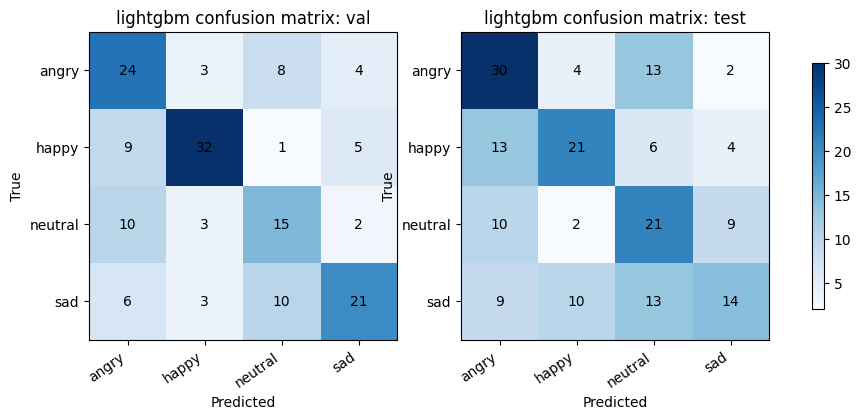

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, split_name, X_split, y_split in [
    (axes[0], 'val', X_val, y_val),
    (axes[1], 'test', X_test, y_test),
]:
    pred = best_model.predict(X_split)
    cm = confusion_matrix(y_split, pred, labels=LABEL_ORDER)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{best_model_name} confusion matrix: {split_name}')
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=35, ha='right')
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

## Feature Ablation Study

In [50]:
def cols_starting_with(prefixes):
    return [c for c in feature_cols if any(c.startswith(prefix) for prefix in prefixes)]

feature_sets = {
    'MFCC only': cols_starting_with(['mfcc_']),
    'LogMel only': cols_starting_with(['logmel_']),
    'Energy + ZCR': cols_starting_with(['rms_', 'zcr_']),
    'Spectral shape': cols_starting_with(['centroid_', 'bandwidth_', 'rolloff_']),
    'All features': feature_cols,
}

ablation_models = {
    'rbf_svm': models['rbf_svm'],
    'lightgbm': models['lightgbm'],
}

ablation_rows = []

for feature_set_name, cols in feature_sets.items():
    if not cols:
        print('Skipping empty feature set:', feature_set_name)
        continue

    X_train_sub = features_df.loc[train_mask, cols].fillna(0)
    X_val_sub = features_df.loc[val_mask, cols].fillna(0)
    X_test_sub = features_df.loc[test_mask, cols].fillna(0)

    for model_name, base_model in ablation_models.items():
        model = clone(base_model)
        try:
            model.fit(X_train_sub, y_train)
            val_pred = model.predict(X_val_sub)
            test_pred = model.predict(X_test_sub)

            ablation_rows.append({
                'feature_set': feature_set_name,
                'model': model_name,
                'n_features': len(cols),
                'val_UAR': balanced_accuracy_score(y_val, val_pred),
                'val_Accuracy': accuracy_score(y_val, val_pred),
                'val_Macro F1': f1_score(y_val, val_pred, average='macro'),
                'test_UAR': balanced_accuracy_score(y_test, test_pred),
                'test_Accuracy': accuracy_score(y_test, test_pred),
                'test_Macro F1': f1_score(y_test, test_pred, average='macro')
            })
        except Exception as e:
            ablation_rows.append({
                'feature_set': feature_set_name,
                'model': model_name,
                'n_features': len(cols),
                'val_UAR': np.nan,
                'val_Accuracy': np.nan,
                'val_Macro F1': np.nan,
                'test_UAR': np.nan,
                'test_Accuracy': np.nan,
                'test_Macro F1': np.nan,
            })
            print(f'{feature_set_name} / {model_name} failed:', repr(e)[:180])

ablation_df = pd.DataFrame(ablation_rows).sort_values(['test_UAR', 'val_UAR'], ascending=False)
display(ablation_df)

,feature_set,model,n_features,val_UAR,val_Accuracy,val_Macro F1,test_UAR,test_Accuracy,test_Macro F1
0,MFCC only,rbf_svm,40,0.525760,0.538462,0.531552,0.527619,0.524862,0.526336
1,MFCC only,lightgbm,40,0.509963,0.519231,0.508166,0.488704,0.486188,0.486927
8,All features,rbf_svm,189,0.487207,0.506410,0.487178,0.483610,0.486188,0.486123
9,All features,lightgbm,189,0.580309,0.589744,0.581203,0.473466,0.475138,0.468624
3,LogMel only,lightgbm,128,0.508589,0.512821,0.508650,0.438355,0.441989,0.434675
7,Spectral shape,lightgbm,12,0.366899,0.365385,0.363669,0.409946,0.403315,0.397668
6,Spectral shape,rbf_svm,12,0.340610,0.346154,0.338509,0.406426,0.397790,0.374712
2,LogMel only,rbf_svm,128,0.455476,0.474359,0.456098,0.387582,0.392265,0.382625
5,Energy + ZCR,lightgbm,8,0.365930,0.371795,0.366507,0.376388,0.370166,0.368256
4,Energy + ZCR,rbf_svm,8,0.375515,0.378205,0.374523,0.362095,0.353591,0.343226


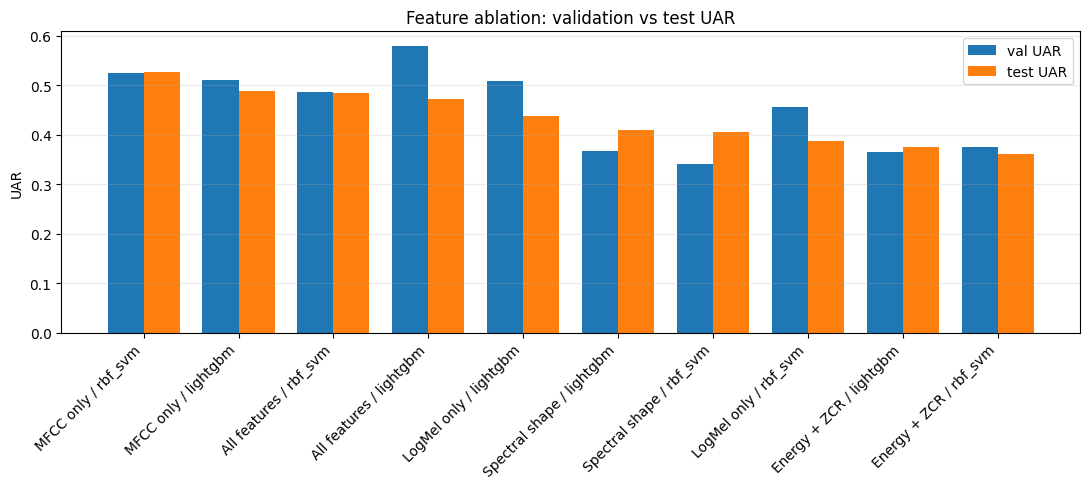

In [52]:
plot_df = ablation_df
plot_df['experiment'] = plot_df['feature_set'] + ' / ' + plot_df['model']

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(plot_df))
width = 0.38

ax.bar(x - width / 2, plot_df['val_UAR'], width, label='val UAR')
ax.bar(x + width / 2, plot_df['test_UAR'], width, label='test UAR')
ax.set_xticks(x, plot_df['experiment'], rotation=45, ha='right')
ax.set_ylabel('UAR')
ax.set_title('Feature ablation: validation vs test UAR')
ax.grid(axis='y', alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

ablation_path = WORK_DIR / 'ua_ser_feature_ablation.csv'
ablation_df.to_csv(ablation_path, index=False)

The ablation study showed that MFCC features alone provided the best generalization among handcrafted acoustic representations. The RBF SVM trained only on MFCC mean/std features achieved the highest test UAR of 0.528, outperforming both the full feature set and more complex LightGBM models. Although LightGBM with all features reached the best validation UAR of 0.582, its test UAR dropped to 0.481, indicating limited generalization. Energy/ZCR and simple spectral-shape features were substantially weaker, suggesting that emotion-relevant cues in this baseline are captured mainly by MFCC-based timbral information rather than simple energy or spectral descriptors.

MFCC only + RBF SVM
Val UAR:  0.526
Test UAR: 0.528

## Best Ablation Model Confusion Matrix

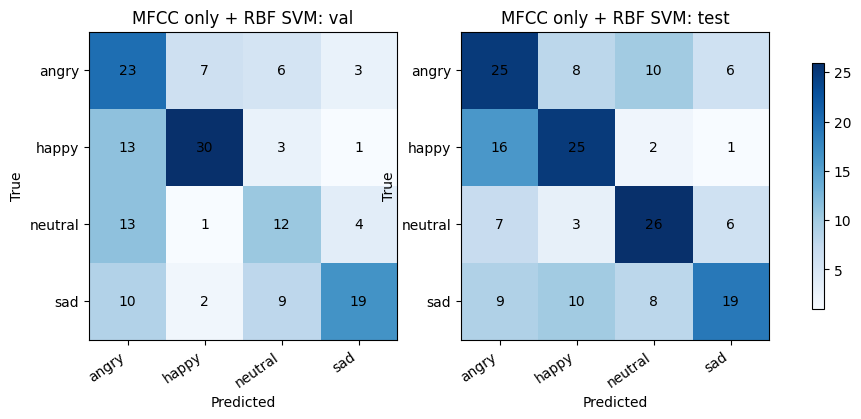

In [54]:
best_ablation_cols = feature_sets['MFCC only']
best_ablation_model = clone(models['rbf_svm'])

X_train_mfcc = features_df.loc[train_mask, best_ablation_cols].fillna(0)
X_val_mfcc = features_df.loc[val_mask, best_ablation_cols].fillna(0)
X_test_mfcc = features_df.loc[test_mask, best_ablation_cols].fillna(0)

best_ablation_model.fit(X_train_mfcc, y_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, split_name, X_split, y_split in [
    (axes[0], 'val', X_val_mfcc, y_val),
    (axes[1], 'test', X_test_mfcc, y_test),
]:
    pred = best_ablation_model.predict(X_split)
    cm = confusion_matrix(y_split, pred, labels=LABEL_ORDER)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'MFCC only + RBF SVM: {split_name}')
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=35, ha='right')
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

## Hard Samples With Audio

In [55]:
from IPython.display import Audio as IPyAudio, Markdown, display

TOP_ERROR_TYPES = 4
SAMPLES_PER_ERROR = 2

# Recompute predictions here so the cell is runnable even after kernel restart.
best_ablation_cols = feature_sets['MFCC only']
best_ablation_model = clone(models['rbf_svm'])

X_train_mfcc = features_df.loc[train_mask, best_ablation_cols].fillna(0)
X_test_mfcc = features_df.loc[test_mask, best_ablation_cols].fillna(0)
best_ablation_model.fit(X_train_mfcc, y_train)
test_pred_mfcc = best_ablation_model.predict(X_test_mfcc)

test_errors_audio = df.loc[
    test_mask,
    ['filename', 'path', 'text', 'emotion', 'gender', 'duration_seconds', 'speaker_id'],
].copy()
test_errors_audio['pred'] = test_pred_mfcc
test_errors_audio['is_error'] = test_errors_audio['emotion'] != test_errors_audio['pred']
test_errors_audio['error_type'] = test_errors_audio['emotion'] + ' -> ' + test_errors_audio['pred']

top_error_types = (
    test_errors_audio.loc[test_errors_audio['is_error'], 'error_type']
    .value_counts()
    .head(TOP_ERROR_TYPES)
)

display(top_error_types.rename_axis('error_type').reset_index(name='count'))

for error_type, count in top_error_types.items():
    display(Markdown(f'### {error_type} | count: {count}'))
    samples = (
        test_errors_audio[test_errors_audio['error_type'] == error_type]
        .sort_values('duration_seconds')
        .head(SAMPLES_PER_ERROR)
    )

    display(samples[['filename', 'text', 'gender', 'duration_seconds', 'speaker_id', 'emotion', 'pred']])

    for _, row in samples.iterrows():
        display(Markdown(f"**{row['filename']}** | true: `{row['emotion']}` | pred: `{row['pred']}` | text: {row['text']}"))
        display(IPyAudio(filename=row['path']))

,error_type,count
0,happy -> angry,16
1,sad -> happy,10
2,angry -> neutral,10
3,sad -> angry,9


### happy -> angry | count: 16

,filename,text,gender,duration_seconds,speaker_id,emotion,pred
488,h_060_1.wav,"Дякую, велике.",female,0.95,120,happy,angry
564,h_136_1.wav,"Да, я розкажу.",female,1.08,38,happy,angry


**h_060_1.wav** | true: `happy` | pred: `angry` | text: Дякую, велике.

**h_136_1.wav** | true: `happy` | pred: `angry` | text: Да, я розкажу.

...

**a_162_0.wav** | true: `angry` | pred: `neutral` | text: Чи є з таким відношенням

### sad -> angry | count: 9

,filename,text,gender,duration_seconds,speaker_id,emotion,pred
945,s_225_1.wav,"Знову, ти мовчиш",female,1.12,393,sad,angry
1,s_002_1.wav,Але я тебе ніколи не бачила.,female,1.54,107,sad,angry


**s_225_1.wav** | true: `sad` | pred: `angry` | text: Знову, ти мовчиш

**s_002_1.wav** | true: `sad` | pred: `angry` | text: Але я тебе ніколи не бачила.

## Self-Supervised Speech Embeddings

In [56]:
import re
import torch
from tqdm.auto import tqdm
from transformers import AutoFeatureExtractor, AutoModel


# SSL_MODEL_NAME = 'facebook/wav2vec2-base'
SSL_MODEL_NAME = 'facebook/wav2vec2-xls-r-300m'
SSL_SAMPLE_RATE = 16_000
SSL_BATCH_SIZE = 2
SSL_MAX_SECONDS = 6.0

# Kaggle can expose a GPU that is incompatible with the installed torch CUDA build.
# Keep True if you see: CUDA error: no kernel image is available for execution on the device.
SSL_FORCE_CPU = True

safe_ssl_name = re.sub(r'[^a-zA-Z0-9]+', '_', SSL_MODEL_NAME).strip('_').lower()
SSL_CACHE = WORK_DIR / f'ua_ser_ssl_embeddings_{safe_ssl_name}.npz'
DEVICE = 'cpu' if SSL_FORCE_CPU else ('cuda' if torch.cuda.is_available() else 'cpu')

torch.manual_seed(SEED)

print('ssl_model:', SSL_MODEL_NAME)
print('device:', DEVICE)
print('force_cpu:', SSL_FORCE_CPU)
print('cache:', SSL_CACHE)
print('batch_size:', SSL_BATCH_SIZE)


ssl_model: facebook/wav2vec2-xls-r-300m
device: cpu
force_cpu: True
cache: /kaggle/working/ua_ser_ssl_embeddings_facebook_wav2vec2_xls_r_300m.npz
batch_size: 2


In [57]:
def read_audio_for_ssl(path, sample_rate=SSL_SAMPLE_RATE, max_seconds=SSL_MAX_SECONDS):
    audio, _ = librosa.load(path, sr=sample_rate, mono=True)
    if max_seconds is not None:
        audio = audio[:int(sample_rate * max_seconds)]
    return audio.astype(np.float32)


def hidden_mean_pool(last_hidden, attention_mask, model):
    if attention_mask is None:
        return last_hidden.mean(dim=1)

    if hasattr(model, '_get_feature_vector_attention_mask'):
        hidden_mask = model._get_feature_vector_attention_mask(last_hidden.shape[1], attention_mask)
        hidden_mask = hidden_mask.to(last_hidden.device).unsqueeze(-1).type_as(last_hidden)
        return (last_hidden * hidden_mask).sum(dim=1) / hidden_mask.sum(dim=1).clamp(min=1.0)

    return last_hidden.mean(dim=1)


def load_ssl_embeddings_cache(cache_path, filenames):
    if not cache_path.exists():
        return None
    cached = np.load(cache_path, allow_pickle=True)
    cached_filenames = cached['filenames'].astype(str)
    if len(cached_filenames) != len(filenames) or not np.all(cached_filenames == filenames):
        print('cache exists, but filenames differ; recomputing')
        return None
    print('loaded cached embeddings')
    return cached['embeddings']

filenames = df['filename'].astype(str).to_numpy()
ssl_embeddings = load_ssl_embeddings_cache(SSL_CACHE, filenames)

if ssl_embeddings is None:
    feature_extractor = AutoFeatureExtractor.from_pretrained(SSL_MODEL_NAME)
    ssl_model = AutoModel.from_pretrained(SSL_MODEL_NAME).to(DEVICE)
    ssl_model.eval()

    all_embeddings = []
    paths = df['path'].astype(str).tolist()

    for start in tqdm(range(0, len(paths), SSL_BATCH_SIZE), desc='SSL embeddings'):
        batch_paths = paths[start:start + SSL_BATCH_SIZE]
        batch_audio = [read_audio_for_ssl(path) for path in batch_paths]
        inputs = feature_extractor(
            batch_audio,
            sampling_rate=SSL_SAMPLE_RATE,
            padding=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        inputs = {key: value.to(DEVICE) for key, value in inputs.items() if torch.is_tensor(value)}

        with torch.no_grad():
            outputs = ssl_model(**inputs)
            pooled = hidden_mean_pool(outputs.last_hidden_state, inputs.get('attention_mask'), ssl_model)

        all_embeddings.append(pooled.cpu().numpy())

    ssl_embeddings = np.vstack(all_embeddings).astype(np.float32)
    np.savez_compressed(
        SSL_CACHE,
        embeddings=ssl_embeddings,
        filenames=filenames,
        model=np.array([SSL_MODEL_NAME]),
    )
    del ssl_model
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

print('ssl_embeddings shape:', ssl_embeddings.shape)
print('saved cache:', SSL_CACHE)


loaded cached embeddings
ssl_embeddings shape: (952, 1024)
saved cache: /kaggle/working/ua_ser_ssl_embeddings_facebook_wav2vec2_xls_r_300m.npz


In [58]:
ssl_X_train = ssl_embeddings[train_mask.to_numpy()]
ssl_X_val = ssl_embeddings[val_mask.to_numpy()]
ssl_X_test = ssl_embeddings[test_mask.to_numpy()]

ssl_models = {
    'ssl_logreg': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    ),
    'ssl_rbf_svm': make_pipeline(
        StandardScaler(),
        SVC(C=3.0, gamma='scale', class_weight='balanced', random_state=SEED),
    ),
    'ssl_lightgbm': LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        class_weight='balanced',
        random_state=SEED,
        verbosity=-1,
    ),
}

ssl_results = []
ssl_fitted_models = {}

for name, model in ssl_models.items():
    try:
        model.fit(ssl_X_train, y_train)
        ssl_fitted_models[name] = model

        row = {'model': name, 'embedding_model': SSL_MODEL_NAME, 'n_features': ssl_X_train.shape[1], 'error': ''}
        for split_name, X_split, y_split in [
            ('val', ssl_X_val, y_val),
            ('test', ssl_X_test, y_test),
        ]:
            pred = model.predict(X_split)
            row[f'{split_name}_UAR'] = balanced_accuracy_score(y_split, pred)
            row[f'{split_name}_Accuracy'] = accuracy_score(y_split, pred)
            row[f'{split_name}_Macro F1'] = f1_score(y_split, pred, average='macro')
        ssl_results.append(row)
    except Exception as e:
        ssl_results.append({
            'model': name,
            'embedding_model': SSL_MODEL_NAME,
            'n_features': ssl_X_train.shape[1],
            'val_UAR': np.nan,
            'val_Accuracy': np.nan,
            'val_Macro F1': np.nan,
            'test_UAR': np.nan,
            'test_Accuracy': np.nan,
            'test_Macro F1': np.nan,
            'error': repr(e)[:180],
        })
        print(f'{name} failed:', repr(e)[:180])

ssl_results_df = pd.DataFrame(ssl_results).sort_values('val_UAR', ascending=False)
display(ssl_results_df)
ssl_results_df.to_csv(WORK_DIR / 'ua_ser_ssl_embedding_baseline.csv', index=False)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,embedding_model,n_features,error,val_UAR,val_Accuracy,val_Macro F1,test_UAR,test_Accuracy,test_Macro F1
0,ssl_logreg,facebook/wav2vec2-xls-r-300m,1024,,0.646328,0.653846,0.643740,0.683149,0.685083,0.681888
1,ssl_rbf_svm,facebook/wav2vec2-xls-r-300m,1024,,0.595015,0.602564,0.590471,0.663012,0.662983,0.663294
2,ssl_lightgbm,facebook/wav2vec2-xls-r-300m,1024,,0.562994,0.576923,0.557038,0.574033,0.574586,0.573955


best SSL validation model: ssl_logreg

val
UAR: 0.6463
Accuracy: 0.6538
Macro F1: 0.6437
              precision    recall  f1-score   support

       angry      0.605     0.590     0.597        39
       happy      0.771     0.787     0.779        47
     neutral      0.487     0.633     0.551        30
         sad      0.742     0.575     0.648        40

    accuracy                          0.654       156
   macro avg      0.651     0.646     0.644       156
weighted avg      0.667     0.654     0.656       156


test
UAR: 0.6831
Accuracy: 0.6851
Macro F1: 0.6819
              precision    recall  f1-score   support

       angry      0.704     0.776     0.738        49
       happy      0.711     0.727     0.719        44
     neutral      0.628     0.643     0.635        42
         sad      0.692     0.587     0.635        46

    accuracy                          0.685       181
   macro avg      0.684     0.683     0.682       181
weighted avg      0.685     0.685     0.683 

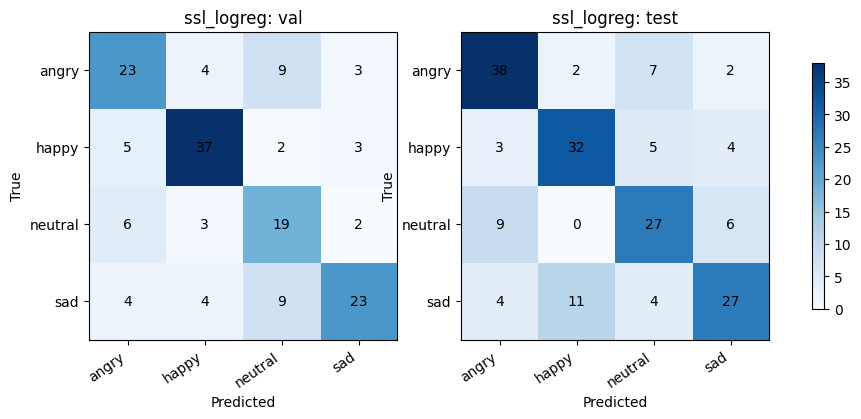

In [59]:
best_ssl_name = ssl_results_df.iloc[0]['model']
best_ssl_model = ssl_fitted_models[best_ssl_name]

print('best SSL validation model:', best_ssl_name)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, split_name, X_split, y_split in [
    (axes[0], 'val', ssl_X_val, y_val),
    (axes[1], 'test', ssl_X_test, y_test),
]:
    pred = best_ssl_model.predict(X_split)
    print()
    print(split_name)
    print('UAR:', round(balanced_accuracy_score(y_split, pred), 4))
    print('Accuracy:', round(accuracy_score(y_split, pred), 4))
    print('Macro F1:', round(f1_score(y_split, pred, average='macro'), 4))
    print(classification_report(y_split, pred, labels=LABEL_ORDER, digits=3, zero_division=0))

    cm = confusion_matrix(y_split, pred, labels=LABEL_ORDER)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'{best_ssl_name}: {split_name}')
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=35, ha='right')
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()


## PyTorch Classifier on SSL Embeddings

In [60]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

if 'ssl_embeddings' not in globals():
    cached = np.load(SSL_CACHE, allow_pickle=True)
    ssl_embeddings = cached['embeddings']
    print('loaded ssl_embeddings from:', SSL_CACHE)

label_to_id = {label: i for i, label in enumerate(LABEL_ORDER)}
id_to_label = {i: label for label, i in label_to_id.items()}

y_train_id = y_train.map(label_to_id).to_numpy()
y_val_id = y_val.map(label_to_id).to_numpy()
y_test_id = y_test.map(label_to_id).to_numpy()

pt_scaler = StandardScaler()
pt_X_train = pt_scaler.fit_transform(ssl_X_train).astype(np.float32)
pt_X_val = pt_scaler.transform(ssl_X_val).astype(np.float32)
pt_X_test = pt_scaler.transform(ssl_X_test).astype(np.float32)

pt_device = 'cuda' if torch.cuda.is_available() and not SSL_FORCE_CPU else 'cpu'
print('pytorch device:', pt_device)
print('train/val/test:', pt_X_train.shape, pt_X_val.shape, pt_X_test.shape)


pytorch device: cpu
train/val/test: (615, 1024) (156, 1024) (181, 1024)


In [61]:
class SSLHead(nn.Module):
    def __init__(self, input_dim, n_classes, head='linear', hidden_dim=256, dropout=0.25):
        super().__init__()
        if head == 'linear':
            self.net = nn.Linear(input_dim, n_classes)
        elif head == 'mlp':
            self.net = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim, n_classes),
            )
        else:
            raise ValueError(f'Unknown head: {head}')

    def forward(self, x):
        return self.net(x)


class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        pt = torch.exp(-ce)
        return ((1 - pt) ** self.gamma * ce).mean()


def make_loader(X, y, batch_size=64, shuffle=False):
    ds = TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def predict_torch_model(model, X, batch_size=256):
    model.eval()
    preds = []
    loader = make_loader(X, np.zeros(len(X), dtype=np.int64), batch_size=batch_size, shuffle=False)
    with torch.no_grad():
        for xb, _ in loader:
            logits = model(xb.to(pt_device))
            preds.append(logits.argmax(dim=1).cpu().numpy())
    return np.concatenate(preds)


def run_torch_ssl_experiment(head='linear', loss_name='ce', noise_std=0.0, epochs=120, patience=20, lr=1e-3):
    torch.manual_seed(SEED)
    np.random.seed(SEED)

    model = SSLHead(pt_X_train.shape[1], len(LABEL_ORDER), head=head).to(pt_device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-3)

    class_counts = np.bincount(y_train_id, minlength=len(LABEL_ORDER))
    class_weights = len(y_train_id) / (len(LABEL_ORDER) * np.maximum(class_counts, 1))
    class_weights = torch.tensor(class_weights, dtype=torch.float32, device=pt_device)

    if loss_name == 'ce':
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    elif loss_name == 'focal':
        criterion = FocalLoss(gamma=2.0, weight=class_weights)
    else:
        raise ValueError(f'Unknown loss: {loss_name}')

    train_loader = make_loader(pt_X_train, y_train_id, batch_size=64, shuffle=True)
    best_state = None
    best_val_uar = -np.inf
    best_epoch = 0
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(pt_device)
            yb = yb.to(pt_device)
            if noise_std > 0:
                xb = xb + torch.randn_like(xb) * noise_std

            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        val_pred_id = predict_torch_model(model, pt_X_val)
        val_pred = [id_to_label[i] for i in val_pred_id]
        val_uar = balanced_accuracy_score(y_val, val_pred)

        if val_uar > best_val_uar:
            best_val_uar = val_uar
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if bad_epochs >= patience:
            break

    model.load_state_dict(best_state)

    row = {
        'Model': f'torch_{head}',
        'Features/Backbone': SSL_MODEL_NAME,
        'Training Objective': {'ce': 'cross_entropy', 'focal': 'focal_loss'}[loss_name],
        'Augmentation': 'embedding_noise' if noise_std > 0 else 'none',
        'Noise Std': noise_std,
        'Best Epoch': best_epoch,
    }

    for split_name, X_split, y_split in [
        ('Val', pt_X_val, y_val),
        ('Test', pt_X_test, y_test),
    ]:
        pred_id = predict_torch_model(model, X_split)
        pred = [id_to_label[i] for i in pred_id]
        row[f'{split_name} UAR'] = balanced_accuracy_score(y_split, pred)
        row[f'{split_name} Accuracy'] = accuracy_score(y_split, pred)
        row[f'{split_name} Macro F1'] = f1_score(y_split, pred, average='macro')

    return row, model


In [62]:
torch_ssl_experiments = [
    {'head': 'linear', 'loss_name': 'ce', 'noise_std': 0.0},
    {'head': 'linear', 'loss_name': 'focal', 'noise_std': 0.0},
    {'head': 'mlp', 'loss_name': 'ce', 'noise_std': 0.0},
    {'head': 'mlp', 'loss_name': 'focal', 'noise_std': 0.0},
    {'head': 'mlp', 'loss_name': 'ce', 'noise_std': 0.03},
    {'head': 'mlp', 'loss_name': 'focal', 'noise_std': 0.03},
]

torch_ssl_rows = []
torch_ssl_models = {}

for cfg in torch_ssl_experiments:
    key = f"{cfg['head']}_{cfg['loss_name']}_noise{cfg['noise_std']}"
    row, model = run_torch_ssl_experiment(**cfg)
    torch_ssl_rows.append(row)
    torch_ssl_models[key] = model

ssl_torch_results_df = pd.DataFrame(torch_ssl_rows).sort_values('Val UAR', ascending=False)
print('torch SSL head ablation rows:', len(ssl_torch_results_df))
ssl_torch_results_df.to_csv(WORK_DIR / 'ua_ser_ssl_torch_head_ablation.csv', index=False)


torch SSL head ablation rows: 6


In [63]:
sklearn_ssl_table = ssl_results_df.rename(columns={
    'model': 'Model',
    'embedding_model': 'Features/Backbone',
    'val_UAR': 'Val UAR',
    'val_Accuracy': 'Val Accuracy',
    'val_Macro F1': 'Val Macro F1',
    'test_UAR': 'Test UAR',
    'test_Accuracy': 'Test Accuracy',
    'test_Macro F1': 'Test Macro F1',
}).copy()
sklearn_objective = {
    'ssl_logreg': 'logistic_loss',
    'ssl_rbf_svm': 'svm_margin',
    'ssl_lightgbm': 'gbdt_logloss',
}
sklearn_ssl_table['Training Objective'] = sklearn_ssl_table['Model'].map(sklearn_objective).fillna('sklearn_objective')
sklearn_ssl_table['Augmentation'] = 'none'
sklearn_ssl_table = sklearn_ssl_table[[
    'Model', 'Features/Backbone', 'Training Objective', 'Augmentation',
    'Val UAR', 'Test UAR', 'Test Accuracy', 'Test Macro F1'
]]

torch_ssl_table_source = ssl_torch_results_df.copy()
if 'Training Objective' not in torch_ssl_table_source.columns and 'Loss' in torch_ssl_table_source.columns:
    torch_objective = {'ce': 'cross_entropy', 'focal': 'focal_loss'}
    torch_ssl_table_source['Training Objective'] = torch_ssl_table_source['Loss'].map(torch_objective).fillna(torch_ssl_table_source['Loss'])

torch_ssl_table = torch_ssl_table_source[[
    'Model', 'Features/Backbone', 'Training Objective', 'Augmentation',
    'Val UAR', 'Test UAR', 'Test Accuracy', 'Test Macro F1'
]].copy()

final_ssl_results_df = pd.concat([sklearn_ssl_table, torch_ssl_table], ignore_index=True)
final_ssl_results_df = final_ssl_results_df.sort_values('Val UAR', ascending=False).reset_index(drop=True)

print('final SSL result rows:', len(final_ssl_results_df))
final_ssl_results_df.to_csv(WORK_DIR / 'ua_ser_final_ssl_results.csv', index=False)


final SSL result rows: 9


In [64]:
def highlight_top_by_column(df, metric_cols, top_n=3, precision=3):
    colors = {
        1: 'background-color: #2e7d32; color: white; font-weight: 700;',
        2: 'background-color: #81c784; color: black; font-weight: 600;',
        3: 'background-color: #dcedc8; color: black;',
    }

    metric_cols = [col for col in metric_cols if col in df.columns]

    def style_column(col):
        styles = pd.Series('', index=col.index)
        if col.name not in metric_cols:
            return styles

        numeric = pd.to_numeric(col, errors='coerce')
        ranks = numeric.rank(method='min', ascending=False)
        for rank, style in colors.items():
            if rank <= top_n:
                styles[ranks == rank] = style
        return styles

    return (
        df.style
        .apply(style_column, axis=0)
        .format({col: f'{{:.{precision}f}}' for col in metric_cols})
    )

ssl_metric_cols = ['Val UAR', 'Test UAR', 'Test Accuracy', 'Test Macro F1']
display(highlight_top_by_column(final_ssl_results_df, ssl_metric_cols, top_n=3))


,Model,Features/Backbone,Loss,Augmentation,Val UAR,Test UAR,Test Accuracy,Test Macro F1
0,torch_linear,facebook/wav2vec2-xls-r-300m,ce,none,0.660,0.692,0.691,0.690
1,torch_linear,facebook/wav2vec2-xls-r-300m,focal,none,0.654,0.678,0.674,0.673
2,ssl_logreg,facebook/wav2vec2-xls-r-300m,sklearn,none,0.646,0.683,0.685,0.682
3,torch_mlp,facebook/wav2vec2-xls-r-300m,ce,none,0.640,0.695,0.696,0.694
4,torch_mlp,facebook/wav2vec2-xls-r-300m,ce,embedding_noise,0.628,0.696,0.696,0.695
5,torch_mlp,facebook/wav2vec2-xls-r-300m,focal,embedding_noise,0.625,0.674,0.674,0.674
6,torch_mlp,facebook/wav2vec2-xls-r-300m,focal,none,0.613,0.704,0.702,0.702
7,ssl_rbf_svm,facebook/wav2vec2-xls-r-300m,sklearn,none,0.595,0.663,0.663,0.663
8,ssl_lightgbm,facebook/wav2vec2-xls-r-300m,sklearn,none,0.563,0.574,0.575,0.574


## Task-Transfer SSL: emotion2vec+

In [66]:
try:
    from funasr import AutoModel as FunASRAutoModel
except ImportError:
    !pip -q install funasr modelscope
    from funasr import AutoModel as FunASRAutoModel

# Hugging Face mirror: emotion2vec/emotion2vec_plus_large
# FunASR's official loading path uses the equivalent ModelScope ID below.
TASK_TRANSFER_HF_REPO = 'emotion2vec/emotion2vec_plus_large'
TASK_TRANSFER_MODEL_ID = 'iic/emotion2vec_plus_large'
TASK_TRANSFER_MODEL_NAME = TASK_TRANSFER_HF_REPO
TASK_TRANSFER_SAFE_NAME = 'emotion2vec_plus_large'
TASK_FORCE_CPU = True
TASK_DEVICE = 'cpu' if TASK_FORCE_CPU else ('cuda:0' if torch.cuda.is_available() else 'cpu')
TASK_CACHE = WORK_DIR / f'ua_ser_task_transfer_embeddings_{TASK_TRANSFER_SAFE_NAME}.npz'

print('task_transfer_hf_repo:', TASK_TRANSFER_HF_REPO)
print('task_transfer_loader_id:', TASK_TRANSFER_MODEL_ID)
print('device:', TASK_DEVICE)
print('cache:', TASK_CACHE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 298.8/298.8 kB 23.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.7/89.7 kB 6.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 449.6/449.6 kB 31.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 kB 46.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 117.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.5/99.5 kB 7.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


task_transfer_hf_repo: emotion2vec/emotion2vec_plus_large
task_transfer_loader_id: iic/emotion2vec_plus_large
device: cpu
cache: /kaggle/working/ua_ser_task_transfer_embeddings_emotion2vec_plus_large.npz


In [67]:
def describe_funasr_result(result, max_items=5):
    item = result[0] if isinstance(result, list) and result else result
    print('result_type:', type(result))
    print('item_type:', type(item))
    if isinstance(item, dict):
        print('keys:', list(item.keys())[:max_items])
        for key, value in list(item.items())[:max_items]:
            if isinstance(value, np.ndarray):
                print(key, 'array', value.shape, value.dtype)
            elif isinstance(value, (list, tuple)):
                print(key, type(value), 'len=', len(value))
            else:
                print(key, type(value), str(value)[:120])


def find_numeric_embedding(obj):
    if isinstance(obj, np.ndarray):
        arr = obj
        if arr.ndim == 1 and arr.size > 16:
            return arr.astype(np.float32)
        if arr.ndim == 2 and arr.shape[-1] > 16:
            return arr.mean(axis=0).astype(np.float32)

    if isinstance(obj, torch.Tensor):
        return find_numeric_embedding(obj.detach().cpu().numpy())

    if isinstance(obj, dict):
        preferred_keys = [
            'feats', 'embedding', 'embeddings', 'xvector', 'hidden_states',
            'sentence_embedding', 'utt_embedding', 'emotion_embedding'
        ]
        for key in preferred_keys:
            if key in obj:
                found = find_numeric_embedding(obj[key])
                if found is not None:
                    return found
        for value in obj.values():
            found = find_numeric_embedding(value)
            if found is not None:
                return found

    if isinstance(obj, (list, tuple)):
        try:
            arr = np.asarray(obj, dtype=np.float32)
            found = find_numeric_embedding(arr)
            if found is not None:
                return found
        except Exception:
            pass
        for value in obj:
            found = find_numeric_embedding(value)
            if found is not None:
                return found

    return None


task_model_kwargs = {
    'model': TASK_TRANSFER_MODEL_ID,
    'device': TASK_DEVICE,
    'disable_update': True,
}
if TASK_TRANSFER_MODEL_ID.startswith('iic/'):
    task_model_kwargs['hub'] = 'ms'

task_transfer_model = FunASRAutoModel(**task_model_kwargs)

smoke_path = df.loc[df['split3'].eq('train'), 'path'].iloc[0]
smoke_result = task_transfer_model.generate(
    input=str(smoke_path),
    granularity='utterance',
    extract_embedding=True,
)
describe_funasr_result(smoke_result)
smoke_embedding = find_numeric_embedding(smoke_result)
print('smoke_embedding_shape:', None if smoke_embedding is None else smoke_embedding.shape)


funasr version: 1.3.9.


2026-06-14 12:03:27,002 - modelscope - INFO - Got 11 files, start to download ...


Processing 11 items:   0%|          | 0.00/11.0 [00:00<?, ?it/s]

2026-06-14 12:18:44,299 - modelscope - INFO - Finish downloading 11 files for repo 'iic/emotion2vec_plus_large'


Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.0.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.1.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.weight, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.2.0.bias, /root/.cache/modelscope/hub/models/iic/emotion2vec_plus_large/model.pt
Warning, miss key in ckpt: modality_encoders.AUDIO.decoder.blocks.3.0.weight, /root/.cache/modelscope/hub/models

rtf_avg: 0.199: 100%|██████████| 1/1 [00:00<00:00,  2.68it/s]                                                                                      

result_type: <class 'list'>
item_type: <class 'dict'>
keys: ['key', 'labels', 'scores', 'feats']
key <class 'str'> s_001_1
labels <class 'list'> len= 9
scores <class 'list'> len= 9
feats array (1024,) float32
smoke_embedding_shape: (1024,)


In [68]:
def load_task_transfer_cache(cache_path, filenames):
    if not cache_path.exists():
        return None
    cached = np.load(cache_path, allow_pickle=True)
    cached_filenames = cached['filenames'].astype(str)
    if len(cached_filenames) != len(filenames) or not np.all(cached_filenames == filenames):
        print('task-transfer cache exists, but filenames differ; recomputing')
        return None
    print('loaded cached task-transfer embeddings')
    return cached['embeddings']


def extract_emotion2vec_embedding(path):
    result = task_transfer_model.generate(
        input=str(path),
        granularity='utterance',
        extract_embedding=True,
    )
    embedding = find_numeric_embedding(result)
    if embedding is None:
        raise ValueError(f'Could not find embedding in FunASR result for {path}')
    return embedding.astype(np.float32)

filenames = df['filename'].astype(str).to_numpy()
task_transfer_embeddings = load_task_transfer_cache(TASK_CACHE, filenames)

if task_transfer_embeddings is None:
    task_embeddings = []
    for path in tqdm(df['path'].astype(str).tolist(), desc='emotion2vec+ embeddings'):
        task_embeddings.append(extract_emotion2vec_embedding(path))

    task_transfer_embeddings = np.vstack(task_embeddings).astype(np.float32)
    np.savez_compressed(
        TASK_CACHE,
        embeddings=task_transfer_embeddings,
        filenames=filenames,
        model=np.array([TASK_TRANSFER_MODEL_ID]),
    )

print('task_transfer_embeddings shape:', task_transfer_embeddings.shape)
print('saved cache:', TASK_CACHE)


emotion2vec+ embeddings:   0%|          | 0/952 [00:00<?, ?it/s]

rtf_avg: 0.144: 100%|██████████| 1/1 [00:00<00:00,  2.24it/s]


task_transfer_embeddings shape: (952, 1024)
saved cache: /kaggle/working/ua_ser_task_transfer_embeddings_emotion2vec_plus_large.npz


In [71]:
task_X_train = task_transfer_embeddings[train_mask.to_numpy()]
task_X_val = task_transfer_embeddings[val_mask.to_numpy()]
task_X_test = task_transfer_embeddings[test_mask.to_numpy()]

task_models = {
    'task_logreg': make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight='balanced', random_state=SEED),
    ),
    'task_rbf_svm': make_pipeline(
        StandardScaler(),
        SVC(C=3.0, gamma='scale', class_weight='balanced', random_state=SEED),
    ),
    'task_lightgbm': LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        class_weight='balanced',
        random_state=SEED,
        verbosity=-1,
    ),
}

task_objective = {
    'task_logreg': 'logistic_loss',
    'task_rbf_svm': 'svm_margin',
    'task_lightgbm': 'gbdt_logloss',
}

task_rows = []
task_fitted_models = {}

for name, model in task_models.items():
    try:
        model.fit(task_X_train, y_train)
        task_fitted_models[name] = model
        row = {
            'Model': name,
            'Transfer Type': 'task-transfer',
            'Features/Backbone': TASK_TRANSFER_MODEL_NAME,
            'Training Objective': task_objective.get(name, 'sklearn_objective'),
            'Augmentation': 'none',
            'n_features': task_X_train.shape[1],
            'error': '',
        }
        for split_name, X_split, y_split in [
            ('Val', task_X_val, y_val),
            ('Test', task_X_test, y_test),
        ]:
            pred = model.predict(X_split)
            row[f'{split_name} UAR'] = balanced_accuracy_score(y_split, pred)
            row[f'{split_name} Accuracy'] = accuracy_score(y_split, pred)
            row[f'{split_name} Macro F1'] = f1_score(y_split, pred, average='macro')
        task_rows.append(row)
    except Exception as e:
        task_rows.append({
            'Model': name,
            'Transfer Type': 'task-transfer',
            'Features/Backbone': TASK_TRANSFER_MODEL_NAME,
            'Training Objective': task_objective.get(name, 'sklearn_objective'),
            'Augmentation': 'none',
            'n_features': task_X_train.shape[1],
            'Val UAR': np.nan,
            'Val Accuracy': np.nan,
            'Val Macro F1': np.nan,
            'Test UAR': np.nan,
            'Test Accuracy': np.nan,
            'Test Macro F1': np.nan,
            'error': repr(e)[:180],
        })
        print(f'{name} failed:', repr(e)[:180])

task_transfer_results_df = pd.DataFrame(task_rows).sort_values('Val UAR', ascending=False)
display(task_transfer_results_df)
task_transfer_results_df.to_csv(WORK_DIR / 'ua_ser_task_transfer_results.csv', index=False)


,Model,Transfer Type,Features/Backbone,Training Objective,Augmentation,n_features,error,Val UAR,Val Accuracy,Val Macro F1,Test UAR,Test Accuracy,Test Macro F1
1,task_rbf_svm,task-transfer,emotion2vec/emotion2vec_plus_large,svm_margin,none,1024,,0.591230,0.608974,0.589816,0.619041,0.618785,0.619559
2,task_lightgbm,task-transfer,emotion2vec/emotion2vec_plus_large,gbdt_logloss,none,1024,,0.562162,0.583333,0.560593,0.588761,0.591160,0.589891
0,task_logreg,task-transfer,emotion2vec/emotion2vec_plus_large,logistic_loss,none,1024,,0.543863,0.564103,0.545770,0.579678,0.580110,0.580657


In [76]:
language_transfer_table = final_ssl_results_df.copy()
if 'Training Objective' not in language_transfer_table.columns and 'Loss' in language_transfer_table.columns:
    objective_by_model = {
        'ssl_logreg': 'logistic_loss',
        'ssl_rbf_svm': 'svm_margin',
        'ssl_lightgbm': 'gbdt_logloss',
    }
    objective_by_loss = {
        'ce': 'cross_entropy',
        'focal': 'focal_loss',
        'sklearn': 'sklearn_objective',
    }
    language_transfer_table['Training Objective'] = (
        language_transfer_table['Model'].map(objective_by_model)
        .fillna(language_transfer_table['Loss'].map(objective_by_loss))
        .fillna(language_transfer_table['Loss'])
    )

language_transfer_table['Transfer Type'] = 'language-transfer'
language_transfer_table = language_transfer_table[[
    'Model', 'Transfer Type', 'Features/Backbone', 'Training Objective', 'Augmentation',
    'Val UAR', 'Test UAR', 'Test Accuracy', 'Test Macro F1'
]]

task_transfer_table = task_transfer_results_df.copy()
if 'Training Objective' not in task_transfer_table.columns and 'Loss' in task_transfer_table.columns:
    task_objective_fallback = {
        'task_logreg': 'logistic_loss',
        'task_rbf_svm': 'svm_margin',
        'task_lightgbm': 'gbdt_logloss',
    }
    task_transfer_table['Training Objective'] = task_transfer_table['Model'].map(task_objective_fallback).fillna(task_transfer_table['Loss'])

task_transfer_table = task_transfer_table[[
    'Model', 'Transfer Type', 'Features/Backbone', 'Training Objective', 'Augmentation',
    'Val UAR', 'Test UAR', 'Test Accuracy', 'Test Macro F1'
]].copy()

transfer_comparison_df = pd.concat(
    [language_transfer_table, task_transfer_table],
    ignore_index=True,
).sort_values('Val UAR', ascending=False).reset_index(drop=True)

transfer_metric_cols = ['Val UAR', 'Test UAR', 'Test Accuracy', 'Test Macro F1']
display(highlight_top_by_column(transfer_comparison_df, transfer_metric_cols, top_n=3))

transfer_comparison_df.to_csv(WORK_DIR / 'ua_ser_language_vs_task_transfer.csv', index=False)


,Model,Transfer Type,Features/Backbone,Training Objective,Augmentation,Val UAR,Test UAR,Test Accuracy,Test Macro F1
0,torch_linear,language-transfer,facebook/wav2vec2-xls-r-300m,cross_entropy,none,0.660,0.692,0.691,0.690
1,torch_linear,language-transfer,facebook/wav2vec2-xls-r-300m,focal_loss,none,0.654,0.678,0.674,0.673
2,ssl_logreg,language-transfer,facebook/wav2vec2-xls-r-300m,logistic_loss,none,0.646,0.683,0.685,0.682
3,torch_mlp,language-transfer,facebook/wav2vec2-xls-r-300m,cross_entropy,none,0.640,0.695,0.696,0.694
4,torch_mlp,language-transfer,facebook/wav2vec2-xls-r-300m,cross_entropy,embedding_noise,0.628,0.696,0.696,0.695
5,torch_mlp,language-transfer,facebook/wav2vec2-xls-r-300m,focal_loss,embedding_noise,0.625,0.674,0.674,0.674
6,torch_mlp,language-transfer,facebook/wav2vec2-xls-r-300m,focal_loss,none,0.613,0.704,0.702,0.702
7,ssl_rbf_svm,language-transfer,facebook/wav2vec2-xls-r-300m,svm_margin,none,0.595,0.663,0.663,0.663
8,task_rbf_svm,task-transfer,emotion2vec/emotion2vec_plus_large,svm_margin,none,0.591,0.619,0.619,0.620
9,ssl_lightgbm,language-transfer,facebook/wav2vec2-xls-r-300m,gbdt_logloss,none,0.563,0.574,0.575,0.574


## Final Selected Model Confusion Matrix

val
UAR: 0.6602
Accuracy: 0.6731
Macro F1: 0.6585
              precision    recall  f1-score   support

       angry      0.639     0.590     0.613        39
       happy      0.800     0.851     0.825        47
     neutral      0.474     0.600     0.529        30
         sad      0.750     0.600     0.667        40

    accuracy                          0.673       156
   macro avg      0.666     0.660     0.659       156
weighted avg      0.684     0.673     0.675       156

test
UAR: 0.692
Accuracy: 0.6906
Macro F1: 0.6898
              precision    recall  f1-score   support

       angry      0.702     0.673     0.688        49
       happy      0.714     0.795     0.753        44
     neutral      0.604     0.690     0.644        42
         sad      0.757     0.609     0.675        46

    accuracy                          0.691       181
   macro avg      0.694     0.692     0.690       181
weighted avg      0.696     0.691     0.690       181



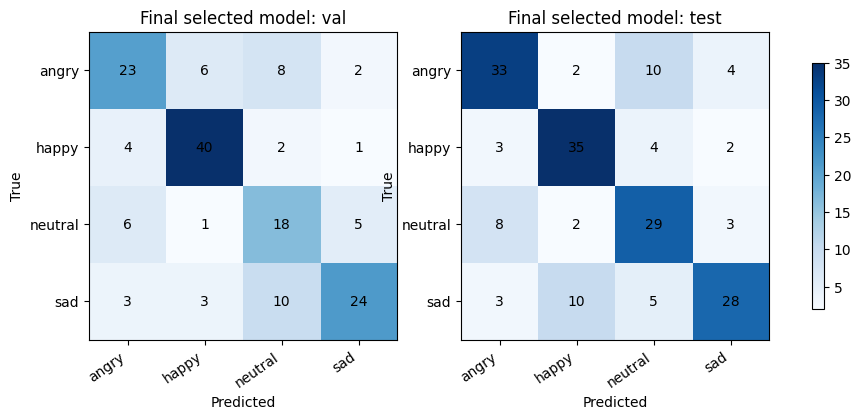

In [77]:
FINAL_MODEL_KEY = 'linear_ce_noise0.0'

if 'torch_ssl_models' in globals() and FINAL_MODEL_KEY in torch_ssl_models:
    final_selected_model = torch_ssl_models[FINAL_MODEL_KEY]
else:
    print('final selected model was not found in memory; retraining the small linear head')
    _, final_selected_model = run_torch_ssl_experiment(head='linear', loss_name='ce', noise_std=0.0)

final_predictions = {}
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, split_name, X_split, y_split in [
    (axes[0], 'val', pt_X_val, y_val),
    (axes[1], 'test', pt_X_test, y_test),
]:
    pred_id = predict_torch_model(final_selected_model, X_split)
    pred = np.array([id_to_label[i] for i in pred_id])
    final_predictions[split_name] = pred

    print(split_name)
    print('UAR:', round(balanced_accuracy_score(y_split, pred), 4))
    print('Accuracy:', round(accuracy_score(y_split, pred), 4))
    print('Macro F1:', round(f1_score(y_split, pred, average='macro'), 4))
    print(classification_report(y_split, pred, labels=LABEL_ORDER, digits=3, zero_division=0))

    cm = confusion_matrix(y_split, pred, labels=LABEL_ORDER)
    im = ax.imshow(cm, cmap='Blues')
    ax.set_title(f'Final selected model: {split_name}')
    ax.set_xticks(range(len(LABEL_ORDER)), LABEL_ORDER, rotation=35, ha='right')
    ax.set_yticks(range(len(LABEL_ORDER)), LABEL_ORDER)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()
